In [ ]:
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

DATA_PATH = os.environ.get("DATA_PATH", "data/train.csv")
RANDOM_STATE = 42
CHUNK_SIZE   = 100_000
HASH_DIM     = 2**18

EDA

In [2]:
df_sample = pd.read_csv(DATA_PATH, nrows=200_000)
print('Shape:', df_sample.shape)
df_sample.head(3)

Shape: (200000, 24)


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,1.000009e+18,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,2,15706,320,50,1722,0,35,-1,79
1,1.000017e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79
2,1.000037e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79


In [3]:
print('Dtypes & missing values:')
info = pd.DataFrame({
    'dtype':   df_sample.dtypes,
    'nunique': df_sample.nunique(),
    'missing': df_sample.isnull().sum()
})
print(info.to_string())

Dtypes & missing values:
                    dtype  nunique  missing
id                float64   200000        0
click               int64        2        0
hour                int64        2        0
C1                  int64        6        0
banner_pos          int64        6        0
site_id            object     1239        0
site_domain        object     1119        0
site_category      object       20        0
app_id             object      989        0
app_domain         object       68        0
app_category       object       19        0
device_id          object    15040        0
device_ip          object    76668        0
device_model       object     3104        0
device_type         int64        4        0
device_conn_type    int64        4        0
C14                 int64      480        0
C15                 int64        5        0
C16                 int64        6        0
C17                 int64      145        0
C18                 int64        4        0
C19    

Class Balance

Overall CTR in sample: 0.1748  (17.48%)


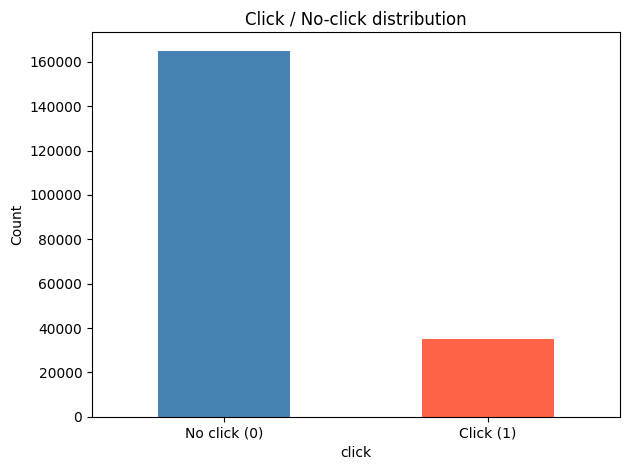


Insight: The dataset is heavily imbalanced — only ~17% clicks.
Log loss is a good metric here because it is sensitive to probability calibration.


In [4]:
click_rate = df_sample['click'].mean()
print(f'Overall CTR in sample: {click_rate:.4f}  ({click_rate*100:.2f}%)')

df_sample['click'].value_counts().plot(kind='bar', color=['steelblue','tomato'],
                                       title='Click / No-click distribution')
plt.xticks([0,1], ['No click (0)', 'Click (1)'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print('\nInsight: The dataset is heavily imbalanced — only ~17% clicks.')
print('Log loss is a good metric here because it is sensitive to probability calibration.')

Feature Cardinality: High cardinality features are hard to one-hot-encode thus we use hashing.

Unique values per feature (sample of 200k rows):
device_ip           76668
device_id           15040
device_model         3104
site_id              1239
site_domain          1119
app_id                989
C14                   480
C20                   149
C17                   145
app_domain             68
C19                    39
C21                    33
site_category          20
app_category           19
C1                      6
banner_pos              6
C16                     6
C15                     5
device_conn_type        4
device_type             4
C18                     4
hour                    2


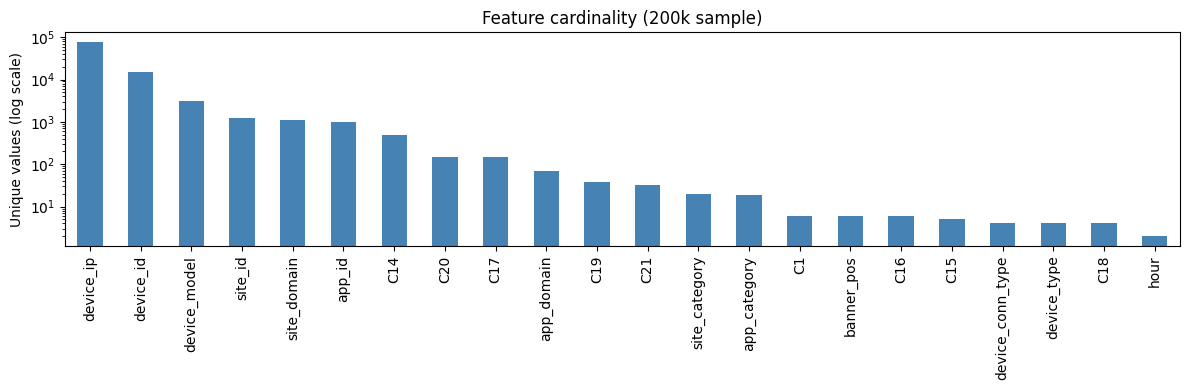

In [5]:
cardinality = df_sample.drop(columns=['id','click']).nunique().sort_values(ascending=False)
print('Unique values per feature (sample of 200k rows):')
print(cardinality.to_string())

cardinality.plot(kind='bar', figsize=(12,4), color='steelblue',
                 title='Feature cardinality (200k sample)')
plt.yscale('log')
plt.ylabel('Unique values (log scale)')
plt.tight_layout()
plt.show()

CTR by hour of day

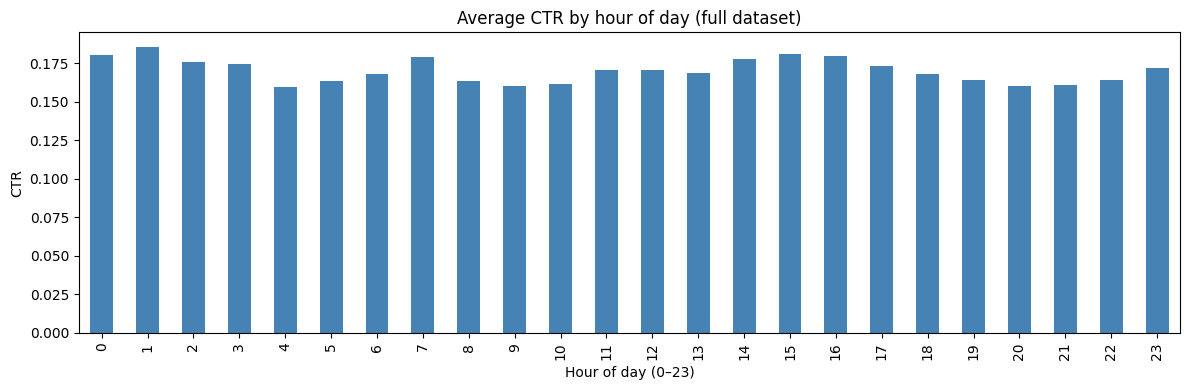

Insight: CTR varies across hours of the day — peak hours show noticeably
higher click rates, confirming hour_of_day is a useful feature.

hour_of_day        0         1         2         3         4         5         6        7         8         9         10        11        12        13        14       15        16        17        18        19        20        21       22        23
CTR          0.180351  0.185774  0.176108  0.174199  0.159567  0.163387  0.168116  0.17919  0.163205  0.160104  0.161256  0.170437  0.170733  0.168434  0.177448  0.18121  0.179445  0.173265  0.168172  0.163996  0.160511  0.160666  0.16384  0.171842


In [6]:
ctr_by_hour = pd.Series(dtype=float)
counts_by_hour = pd.Series(dtype=int)

reader_hour = pd.read_csv(DATA_PATH, usecols=['hour', 'click'], chunksize=CHUNK_SIZE)
for chunk in reader_hour:
    chunk['hour_of_day'] = chunk['hour'].astype(str).str[-2:].astype(int)
    grp = chunk.groupby('hour_of_day')['click']
    ctr_by_hour    = ctr_by_hour.add(grp.sum(),    fill_value=0)
    counts_by_hour = counts_by_hour.add(grp.count(), fill_value=0)

ctr_by_hour = (ctr_by_hour / counts_by_hour).sort_index()

ctr_by_hour.plot(kind='bar', figsize=(12, 4), color='steelblue',
                 title='Average CTR by hour of day (full dataset)')
plt.ylabel('CTR')
plt.xlabel('Hour of day (0–23)')
plt.tight_layout()
plt.show()

print('Insight: CTR varies across hours of the day — peak hours show noticeably')
print('higher click rates, confirming hour_of_day is a useful feature.')
print()
print(ctr_by_hour.rename('CTR').to_frame().T.to_string())

CTR by banner position

In [7]:
ctr_by_pos = df_sample.groupby('banner_pos')['click'].mean().sort_values(ascending=False)
print('CTR by banner position:')
print(ctr_by_pos.to_string())
print('\nInsight: Banner position 7 has the highest CTR — position is a useful feature.')

CTR by banner position:
banner_pos
5    0.411765
4    0.250000
1    0.204894
0    0.166924
2    0.098039
7    0.000000

Insight: Banner position 7 has the highest CTR — position is a useful feature.


Feature Selection

In [8]:
FEATURES = [
    'hour_of_day',   # engineered from 'hour'
    'C1',
    'banner_pos',
    'site_id',
    'site_domain',
    'site_category',
    'app_id',
    'app_domain',
    'app_category',
    'device_model',
    'device_type',
    'device_conn_type',
    'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21',
]
TARGET = 'click'

print(f'Using {len(FEATURES)} features.')

Using 20 features.


Instead of mapping each category value to a column index via a lookup table, we **compute the column index directly from the value using a hash function**:

```
column index = hash("site_id__abc123") mod 262144
```

Every unique string maps deterministically to one of `HASH_DIM = 2^18 = 262 144` columns. No vocabulary needed — we can encode any value we have never seen before.

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import log_loss
from sklearn.feature_extraction import FeatureHasher

In [ ]:
hasher = FeatureHasher(n_features=HASH_DIM, input_type='string')

def preprocess_chunk(df_chunk):
    """Return sparse X and y arrays for one mini-batch."""
    df_chunk = df_chunk.copy()
    df_chunk['hour_of_day'] = df_chunk['hour'].astype(str).str[-2:]

    # Build "col__val" strings vectorized across all rows for each column.
    # cols_prefixed is a list of 20 arrays, each of length chunk_size.
    cols_prefixed = [
        (col + '__' + df_chunk[col].astype(str)).values
        for col in FEATURES
    ]
    # zip(*...) transposes: gives one tuple of 20 strings per row — no Python row loop.
    records = list(zip(*cols_prefixed))

    X = hasher.transform(records)
    y = df_chunk[TARGET].values
    return X, y

print('Preprocessor ready. Feature space dimension:', HASH_DIM)

### Logistic Regression (SGD)
### Naïve Bayes (BernoulliNB)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=df_sample['click'].values
)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print(f'Class weights: {class_weight_dict}')

sgd_model = SGDClassifier(
    loss='log_loss',
    alpha=1e-5,
    class_weight=class_weight_dict,   
    random_state=RANDOM_STATE,
    max_iter=1,
    tol=None,
)

nb_model = BernoulliNB(alpha=1.0)

CLASSES = np.array([0, 1])

print('Models defined.')

Train / Test Split Strategy

In [ ]:
row_count = 0
split_row = None

reader = pd.read_csv(DATA_PATH, usecols=['hour'], chunksize=CHUNK_SIZE)
for chunk in reader:
    if split_row is None:
        last_day_mask = chunk['hour'].astype(str).str[:6] == '141030'
        if last_day_mask.any():
            split_row = row_count + last_day_mask.idxmax() - chunk.index[0]
    row_count += len(chunk)

print(f'Total rows:  {row_count:,}')
print(f'Split at row: {split_row:,}  ({split_row/row_count*100:.1f}% train)')